# Problem Setup
Input: 
- Medical image
- Natural Language question

Output:
- Short textual answer (classification)

In [1]:
import os
import re
import json
from collections import Counter
from PIL import Image
import torch
import torch.nn as nn 
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

### **1. Data Preprocessing**

- Using ImageNet's mean and stddev:
    - [stackoverflow discussion](https://stackoverflow.com/questions/58151507/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-2)
    - [PyTorch documentation](https://docs.pytorch.org/vision/stable/models.html)

In [2]:
# 1.1 Image transformation
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

In [3]:
# 1.2 Text tokenization
# Simple word-level tokenizer
def tokenize(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z0-9 ]", "", sentence)
    return sentence.split()

# Build vocab
def build_vocab(questions, min_freq=1):
    counter = Counter()
    for q in questions:
        counter.update(tokenize(q))

    vocab = {
        "<pad>": 0, 
        "<unk>": 1
    }

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Encode question
def encode_question(question, vocab, max_len=20):
    tokens = tokenize(question)
    ids = [vocab.get(w, vocab["<unk>"]) for w in tokens]
    ids = ids[:max_len]
    return ids + [vocab["<pad>"]] * (max_len - len(ids))

# Answer vocab
def build_answer_vocab(answers):
    answers = [str(a).lower().strip() for a in answers]
    unique_answers = sorted(set(answers))

    answer_to_idx = {"<unk_ans>": 0}        # Solving missing val answers problem
    for ans in unique_answers:
        answer_to_idx[ans] = len(answer_to_idx)

    idx_to_answer = {i: a for a, i in answer_to_idx.items()}
    return answer_to_idx, idx_to_answer

In [4]:
# 1.3 Custom dataset class
class VqaRadDataset(Dataset):
    def __init__(self, json_path, image_dir, vocab, answer_to_idx, transform=None):
        with open(json_path) as f:
            self.data = json.load(f)
        
        self.image_dir = image_dir
        self.vocab = vocab
        self.answer_to_idx = answer_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        item = self.data[index]

        # Load image
        image_path = os.path.join(self.image_dir, item['image_name'])
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Encode question
        question = torch.tensor(
            encode_question(item['question'], self.vocab), 
            dtype=torch.long
        )

        answer_text = str(item['answer']).lower().strip()
        answer_idx = self.answer_to_idx.get(
            answer_text,
            self.answer_to_idx["<unk_ans>"]
        )

        answer = torch.tensor(
            answer_idx, 
            dtype=torch.long
        )

        return image, question, answer

***Sanity Check***

In [5]:
with open("VQA_RAD/train.json", "r") as f:
    train_data = json.load(f)

# Extract questions from train data
trans_questions = [item["question"] for item in train_data]
vocab = build_vocab(trans_questions)

print("Vocab size:", len(vocab))

# Extract answers from train data
train_answers = [item["answer"] for item in train_data]
answer_to_idx, idx_to_answer = build_answer_vocab(train_answers)

print("Number of answer classes:", len(answer_to_idx))
print(answer_to_idx)

Vocab size: 1016
Number of answer classes: 397
{'<unk_ans>': 0, '10-20 minutes': 1, '12': 2, '2': 3, '2.5cm x 1.7cm x 1.6cm': 4, '3.4 cm': 5, '3rd rib': 6, '4': 7, '4th and 5th': 8, '4th ventricle': 9, '5 cm': 10, '5%': 11, '5.6cm focal, predominantly hypodense': 12, '5cm': 13, '7th rib': 14, 'a bit': 15, 'a bullous lesion': 16, 'a catheter': 17, 'abdomen': 18, 'abdomen and pelvis': 19, 'abdominal pain': 20, 'abnormal': 21, 'above the clavicles bilaterally': 22, 'abscess': 23, 'adenopathy': 24, 'adipose tissue': 25, 'adjacent to vertebrae': 26, 'air fluid level': 27, 'air?': 28, 'almost entire right side': 29, 'anterior cerebrum': 30, 'anterior mediastinum': 31, 'anterior surface': 32, 'anterior to the transverse colon': 33, 'aorta enhancement': 34, 'aorta is bright': 35, 'appendicitis': 36, 'appendix': 37, 'ascending colon': 38, 'ascites': 39, 'asymmetric': 40, 'atherosclerotic calcification': 41, 'axial': 42, 'axial plane': 43, 'basal ganglia': 44, 'basal ganglia (caudate and putamen

In [6]:
missing = set()

with open("VQA_RAD/val.json", "r") as f:
    val_data = json.load(f)

for item in val_data:
    ans = str(item["answer"]).strip().lower()
    if ans not in answer_to_idx:
        missing.add(ans)

print("Unseen answers in val data:", missing)
print("Number of missing answers:", len(missing))

Unseen answers in val data: {'right pca', 'epidural hematoma', 'adjacent to the appendix', 'respiratory \tcardia c\tmusculoskeletal', 'cva', 'all three vascular distributions', 'infarcts', 'chest xray', 'partial silhouetting', 'not seen here', 'kidney cyst', '6.5 x 6.2 x 8.8cm', 'small subdural hematoma with cerebral edema', 'blood vessel', 'hyperintense', 'hypodense lesion', 'below the 7th rib in the right lung.', 'ischemia', 'fluid', 'abnormal hyperintensity in the right occipital lobe', 'diffusion weighted imaging (dwi)', 'nothing', 'csf is white', 'free air', 'breasts', 'hepatocellular carcioma', 'metastasis', 'concave', 'portal vein', 'calcified atherosclerosis', 'cardiomegaly with pulmonary edema', 'the base of the cecum', 'right lung hilum', 'well-circumscribed', 'mucosal hyperemia', 'crescent', 'thalami, left occipital lobe, brainstem and left cerebellum', 'pneumonia', 'punctate', 'there is massive cerebral hemisphere edema', 'right convexity', 'above', 'surrounding tissue', 'a

In [7]:
# 1.4 Initialize dataset
DATA_ROOT = "VQA_RAD"
IMAGE_DIR = f"{DATA_ROOT}/images"

train_dataset = VqaRadDataset(
    json_path=f"{DATA_ROOT}/train.json",
    image_dir=IMAGE_DIR,
    vocab=vocab,
    answer_to_idx=answer_to_idx,
    transform=image_transform
)

val_dataset = VqaRadDataset(
    json_path=f"{DATA_ROOT}/val.json",
    image_dir=IMAGE_DIR,
    vocab=vocab,
    answer_to_idx=answer_to_idx,
    transform=image_transform
)

test_dataset = VqaRadDataset(
    json_path=f"{DATA_ROOT}/test.json",
    image_dir=IMAGE_DIR,
    vocab=vocab,
    answer_to_idx=answer_to_idx,
    transform=image_transform
)

In [8]:
# 1.5 Initialize DataLoader
BATCH_SIZE = 32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [9]:
# Verifying batch
image, question, answer = next(iter(train_loader))

print(image.shape)
print(question.shape)
print(answer.shape)

/Users/alyani/Desktop/grad school/WOA7015/Final Assessment/FINAL_ASSESSMENT_WOA7015/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


torch.Size([32, 3, 224, 224])
torch.Size([32, 20])
torch.Size([32])


### **2. Model Architecture**
- CNN (image) + LSTM (text) -> Fusion (Classifier)

In [10]:
# 2.1 Image encoder (CNN)
class ImageEncoder(nn.Module):

    def __init__(self, output_dim=512):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        self.image_fc = nn.Linear(512, output_dim)

    def forward(self, x):
        x = self.cnn(x).squeeze()
        return self.image_fc(x)

In [11]:
# 2.2 Text input encoder (LSTM)
class TextInputEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=300, hidden_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h, _) = self.lstm(emb)
        return h[-1]

In [12]:
# 2.3 VQA Model (Fusion)
class VQAModel(nn.Module):
    def __init__(self, vocab_size, num_answers):
        super().__init__()
        self.image_encoder = ImageEncoder()
        self.text_input_encoder = TextInputEncoder(vocab_size)

        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_answers)
        )

    def forward(self, image, question):
        img_features = self.image_encoder(image)
        ques_feature = self.text_input_encoder(question)
        fused = torch.cat([img_features, ques_feature], dim=1)
        return self.classifier(fused)

### **3. Model Training & Evaluation**

In [13]:
# 3.1 Evaluation function
def eval(model, loader):
    model.eval()
    error = 0
    total = 0

    with torch.no_grad():
        for images, questions, answers in loader:
            outputs = model(images, questions)
            preds = torch.argmax(outputs, dim=1)
            error += (preds != answers).sum().item()
            total += answers.size(0)

    return round((1 - error) / total, 2)

In [14]:
# 3.2 Training pipeline
model = VQAModel(vocab_size=len(vocab), num_answers=len(answer_to_idx))
# model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 10

# Variables for plotting
training_losses, training_accuracies = [], []
validation_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    total_training = 0
    training_error = 0

    for images, questions, answers in train_loader:
        #images, questions, answers = images.to(device), questions.to(device), answers.to(device)

        optimizer.zero_grad()
        outputs = model(images, questions)
        loss = criterion(outputs, answers)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        training_error += (preds != answers).sum().item()
        total_training += answers.size(0)

    
    avg_training_loss = round(total_loss / len(train_loader), 4)
    training_accuracy = round(100 * (1 - training_error / total_training), 2)

    training_losses.append(avg_training_loss)
    training_accuracies.append(training_accuracy)

    validation_accuracy = eval(model, val_loader)
    validation_accuracies.append(validation_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] | Training Loss: {avg_training_loss} | Training Accuracy: {training_accuracy:.2f}% | Validation Accuracy: {validation_accuracy:.2f}%")

/Users/alyani/Desktop/grad school/WOA7015/Final Assessment/FINAL_ASSESSMENT_WOA7015/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/alyani/Desktop/grad school/WOA7015/Final Assessment/FINAL_ASSESSMENT_WOA7015/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/10] | Training Loss: 4.4471 | Training Accuracy: 27.69% | Validation Accuracy: -0.71%
Epoch [2/10] | Training Loss: 3.6502 | Training Accuracy: 34.35% | Validation Accuracy: -0.73%
Epoch [3/10] | Training Loss: 3.1731 | Training Accuracy: 38.09% | Validation Accuracy: -0.68%
Epoch [4/10] | Training Loss: 2.8617 | Training Accuracy: 40.87% | Validation Accuracy: -0.71%
Epoch [5/10] | Training Loss: 2.6501 | Training Accuracy: 43.35% | Validation Accuracy: -0.70%
Epoch [6/10] | Training Loss: 2.4648 | Training Accuracy: 45.63% | Validation Accuracy: -0.74%
Epoch [7/10] | Training Loss: 2.2809 | Training Accuracy: 46.89% | Validation Accuracy: -0.71%
Epoch [8/10] | Training Loss: 2.1034 | Training Accuracy: 48.67% | Validation Accuracy: -0.67%
Epoch [9/10] | Training Loss: 1.9246 | Training Accuracy: 50.63% | Validation Accuracy: -0.69%
Epoch [10/10] | Training Loss: 1.7609 | Training Accuracy: 52.41% | Validation Accuracy: -0.69%


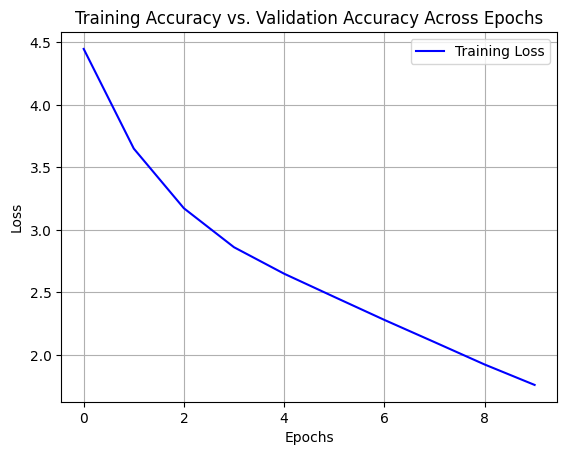

In [15]:
# Loss plot
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(training_losses, label='Training Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Accuracy vs. Validation Accuracy Across Epochs')
plt.grid(True)
plt.legend()
plt.show()

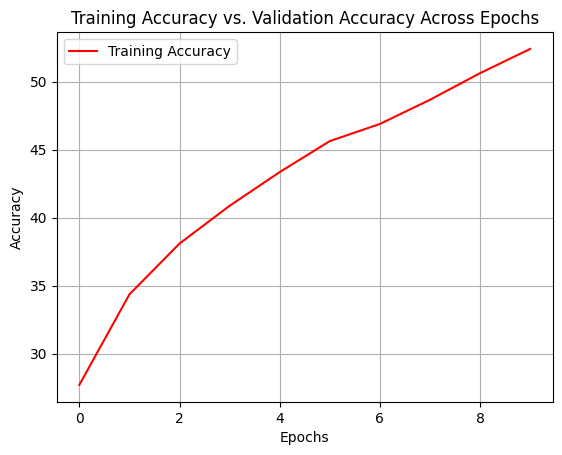

In [16]:
# Accuracy plot
plt.plot(training_accuracies, label='Training Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy vs. Validation Accuracy Across Epochs')
plt.grid(True)
plt.legend()
plt.show()

### **4. Testing Pipeline**

In [17]:
test_accuracy = eval(model, test_loader)
print(f"Final Test Accuracy: {test_accuracy:.2f}")

/Users/alyani/Desktop/grad school/WOA7015/Final Assessment/FINAL_ASSESSMENT_WOA7015/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Final Test Accuracy: -0.68


lol 🥲